# **Stock Market Sentiment Analysis**

This project focuses on performing sentiment analysis on stock market news headlines. It scrapes news data, processes it, and applies two different sentiment analysis techniques — VADER (Valence Aware Dictionary and sEntiment Reasoner) and TextBlob. The project helps determine whether news articles about certain stocks have a positive, neutral, or negative sentiment.
New Section

## **Features**

Extracts stock market-related news data from multiple CSV files stored in a ZIP archive.
Cleans and preprocesses the data, handling invalid or redundant entries.
Applies sentiment analysis using the VADER sentiment analyzer.
Outputs a CSV file with sorted data by stock ticker and date, along with corresponding sentiment scores.

## **Ensure you have the following installed on your system:**
Python 3.x

pip (Python package manager)

## **Libraries Required**

pandas: For handling data in DataFrames.

zipfile: To handle reading ZIP files.

vaderSentiment: For sentiment analysis using the VADER method.

TextBlob: For alternative sentiment analysis (not used in the main code but required if needed).

matplotlib: For future visualization (if needed).

In [ ]:
import zipfile  # Library to handle zip file operations
import pandas as pd  # Library for handling data in DataFrames
!pip install vaderSentiment  # Install VADER Sentiment Analysis
!pip install textblob  # Install TextBlob for sentiment analysis
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer  # VADER Sentiment Analyzer for text
from textblob import TextBlob  # TextBlob for another sentiment analysis method
import matplotlib.pyplot as plt  # Library for plotting

# Path to the downloaded zip file
zip_file_path = '/content/stock-market-Sentiment-analysis-main.zip'

# Create an empty list to store individual DataFrames from each CSV file
dataframes = []

# Open the zip file for reading
with zipfile.ZipFile(zip_file_path, 'r') as z:
    # List all file names inside the zip archive
    file_names = z.namelist()

    # Filter to get only CSV files (you can adjust this if there are other file types)
    csv_files = [f for f in file_names if f.endswith('.csv')]

    # Loop through each CSV file
    for csv_file in csv_files:
        # Open each file and read its content
        with z.open(csv_file) as f:
            # Load the content as a pandas DataFrame
            df = pd.read_csv(f)

            # Append the DataFrame to the list of dataframes
            dataframes.append(df)

# Concatenate all the DataFrames from the list into a single DataFrame
merged_df = pd.concat(dataframes, ignore_index=True)

# Remove rows where the 'Date' column contains the string 'today'
# This ensures that invalid or irrelevant rows are filtered out
merged_df = merged_df[~merged_df['Date'].str.contains('today', case=False, na=False)]

# Remove duplicate rows to ensure each news article is unique
merged_df = merged_df.drop_duplicates()

# Ensure that the 'Date' column is converted into a datetime object
# This helps in properly sorting and handling date-based operations
# 'errors="coerce"' will handle invalid date formats by converting them to NaT (Not a Time)
merged_df['Date'] = pd.to_datetime(merged_df['Date'], errors='coerce')

# Sort the DataFrame by 'Ticker' (the stock ticker) and 'Date' in ascending order
df_sorted = merged_df.sort_values(by=['Ticker', 'Date'], ascending=[True, True])

# Display the first few rows of the sorted DataFrame to verify the sorting operation
print(df_sorted.head())

# Initialize the VADER sentiment analyzer
vader_analyzer = SentimentIntensityAnalyzer()

# Define a function to calculate the compound sentiment score using VADER
# The 'compound' score is a normalized sentiment score ranging from -1 (negative) to +1 (positive)
def vader_sentiment(text):
    return vader_analyzer.polarity_scores(text)['compound']

# Apply the VADER sentiment analysis to the 'Title' column (assuming it contains the news headlines or text)
# Create a new column 'VADER_Sentiment' to store the sentiment score for each row
df_sorted['VADER_Sentiment'] = df_sorted['Title'].apply(vader_sentiment)

# Display the first few rows of the DataFrame to verify the sentiment scores
print(df_sorted.head())

# Optionally, save the final sorted DataFrame (with sentiment analysis) to a new CSV file
df_sorted.to_csv('sorted_output.csv', index=False)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.2 MB/s eta 0:00:00
    Ticker       Date     Time  \
291   AAPL 2024-09-10  11:45PM   
292   AAPL 2024-09-10  11:44PM   
293   AAPL 2024-09-10  11:07PM   
294   AAPL 2024-09-10  10:44PM   
295   AAPL 2024-09-10  10:15PM   

                                                 Title  
291                                  Apple punts on AI  
292  Harris Says Trump Sold Us Out to China, Slams ...  
293  Light guide plate maker GLT to complete Vietna...  
294  Apple Intelligence receives mixed reactions, h...  
295  First phone release in 6 years on same day: Hu...  
    Ticker       Date     Time  \
291   AAPL 2024-09-10  11:45PM   
292   AAPL 2024-09-10  11:44PM   
293   AAPL 2024-09-10  11:07PM   
294   AAPL 2024-09-10  10:44PM   
295   AAPL 2024-09-10  10:15PM   

                                                 Title  VADER_Sentiment  
291                                  Apple punts on AI           0.0000  
292  Harris Says Tru

<ipython-input-2-9b7038606c4a>:46: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  merged_df['Date'] = pd.to_datetime(merged_df['Date'], errors='coerce')


# **Distribution of VADER Sentiment Scores**

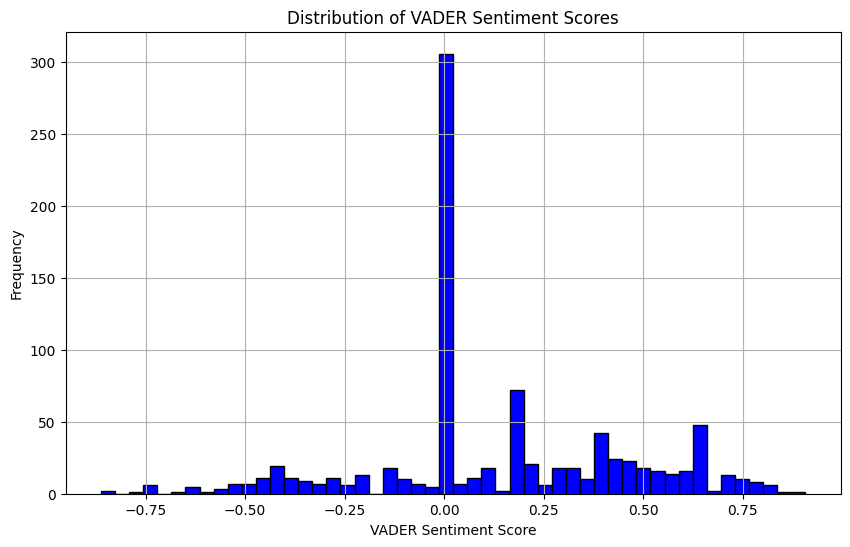

In [ ]:

# Plot distribution of VADER sentiment scores
plt.figure(figsize=(10, 6))
# The 'bins=50' parameter sets the number of bins for the histogram (i.e., the granularity)
df_sorted['VADER_Sentiment'].hist(bins=50, color='blue', edgecolor='black')# 'color' defines the color of the bars, 'edgecolor' adds a black border around each bar
plt.title('Distribution of VADER Sentiment Scores')
plt.xlabel('VADER Sentiment Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()# Display the plot

# **Sentiment Comparison Across Stocks**

<Figure size 1200x800 with 0 Axes>

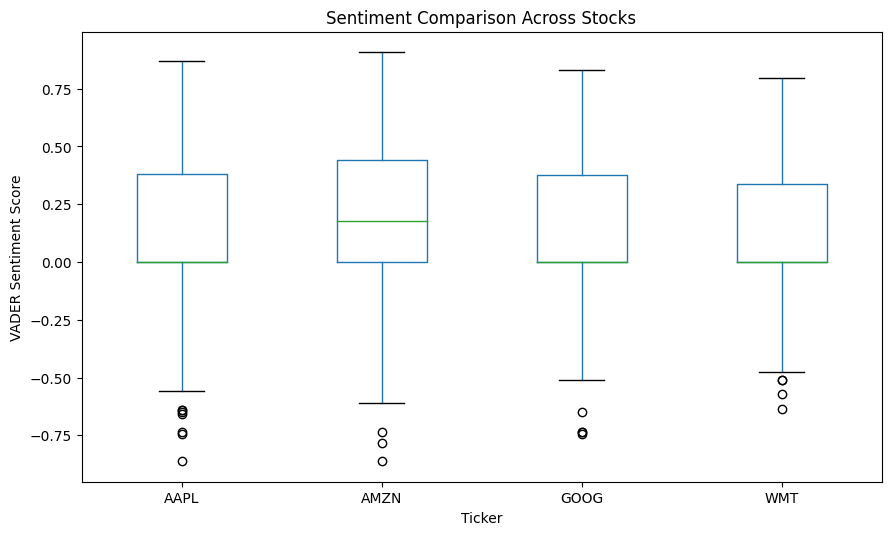

In [ ]:
# Boxplot for multiple tickers
plt.figure(figsize=(12, 8))
# 'by' specifies the grouping factor (here, 'Ticker')
# 'grid=False' turns off the default grid for the plot
df_sorted.boxplot(column='VADER_Sentiment', by='Ticker', grid=False, figsize=(10,6))
plt.title('Sentiment Comparison Across Stocks')
plt.suptitle('')  # Suppress the default title to avoid overlap
plt.xlabel('Ticker')
plt.ylabel('VADER Sentiment Score')
plt.show()# Display the plot

# **Distribution of Sentiment Categories**

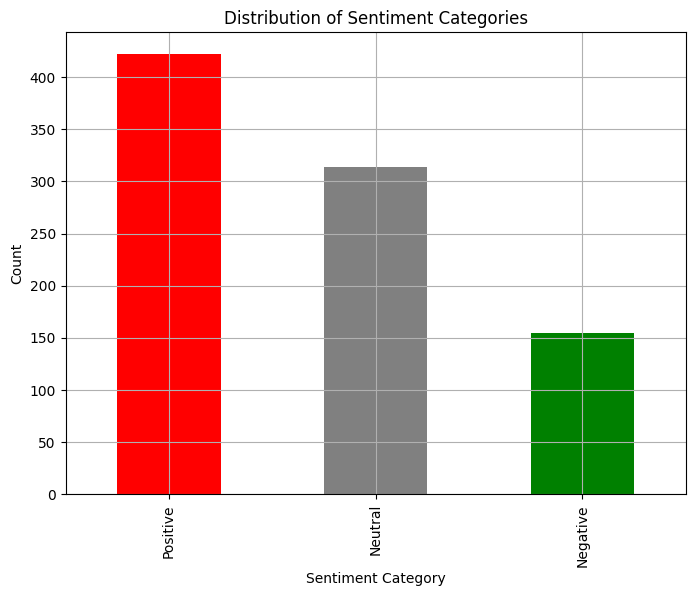

In [ ]:
# Categorize sentiment
# We define three categories: Negative, Neutral, and Positive
# 'bins' specify the boundaries: -1 to -0.05 for Negative, -0.05 to 0.05 for Neutral, and 0.05 to 1 for Positive
df_sorted['Sentiment_Category'] = pd.cut(df_sorted['VADER_Sentiment'], bins=[-1, -0.05, 0.05, 1], labels=['Negative', 'Neutral', 'Positive'])

# Bar chart of sentiment categories
plt.figure(figsize=(8, 6))
# 'plot(kind='bar')' generates a bar chart from these counts
# 'color' specifies the colors for the bars: red for Negative, gray for Neutral, and green for Positive
df_sorted['Sentiment_Category'].value_counts().plot(kind='bar', color=['red', 'gray', 'green'])
plt.title('Distribution of Sentiment Categories')
plt.xlabel('Sentiment Category')
plt.ylabel('Count')
plt.grid(True)
plt.show()# Display the plot

# **Word Cloud of Article Titles**

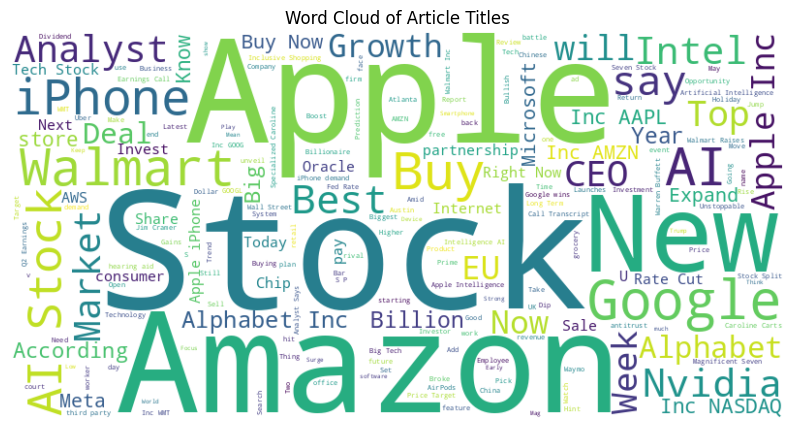

In [ ]:
from wordcloud import WordCloud

# Join all titles into one large string, ensuring that any NaN values are dropped
text = ' '.join(df_sorted['Title'].dropna().tolist())

# Generate the word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display the word cloud
plt.figure(figsize=(10, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Article Titles')
plt.show()# Display the plot

# **Average VADER Sentiment Score**

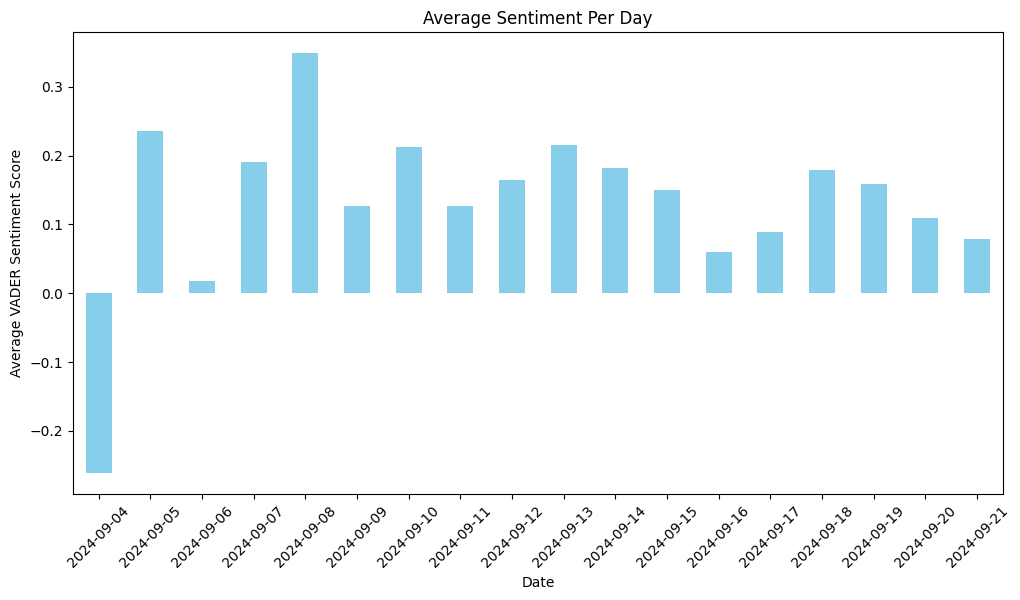

In [ ]:
# Group the sentiment by date and calculate the average sentiment score for each day
daily_sentiment = df_sorted.groupby('Date')['VADER_Sentiment'].mean()

# Convert the date index to a string format without the time component
# This makes the date labels easier to read in the plot
daily_sentiment.index = daily_sentiment.index.strftime('%Y-%m-%d')

# Bar plot of average daily sentiment
plt.figure(figsize=(12, 6))
daily_sentiment.plot(kind='bar', color='skyblue') # Generate a bar plot with a light blue color
plt.title('Average Sentiment Per Day')
plt.xlabel('Date')
plt.ylabel('Average VADER Sentiment Score')
plt.xticks(rotation=45)
plt.show()# Display the plot


# **Sentiment Heatmap for Different Stocks Over Time**

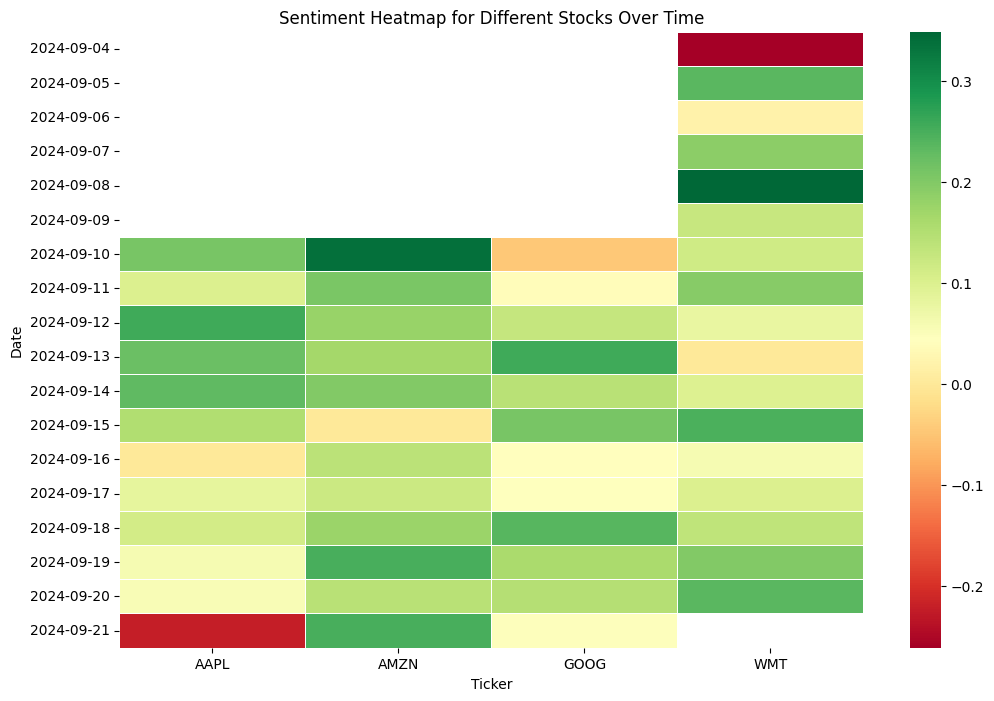

In [ ]:
# Import seaborn for generating the heatmap
import seaborn as sns

# Create a pivot table for the heatmap, where the rows are dates, the columns are tickers,
# and the values are the VADER sentiment scores
pivot_df = df_sorted.pivot_table(index='Date', columns='Ticker', values='VADER_Sentiment')

# Convert the date index to just the date without the time component
# This makes the date labels more readable in the heatmap
pivot_df.index = pivot_df.index.strftime('%Y-%m-%d')

# Plot the heatmap of sentiment over time for different tickers
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_df, cmap='RdYlGn', linewidths=0.5, annot=False)  # Generate the heatmap
# 'cmap="RdYlGn"' defines the color scale: red for negative, yellow for neutral, green for positive sentiment
# 'linewidths=0.5' adds space between the cells in the heatmap

plt.title('Sentiment Heatmap for Different Stocks Over Time')

# Display the heatmap
plt.show()

# **Number of Articles**

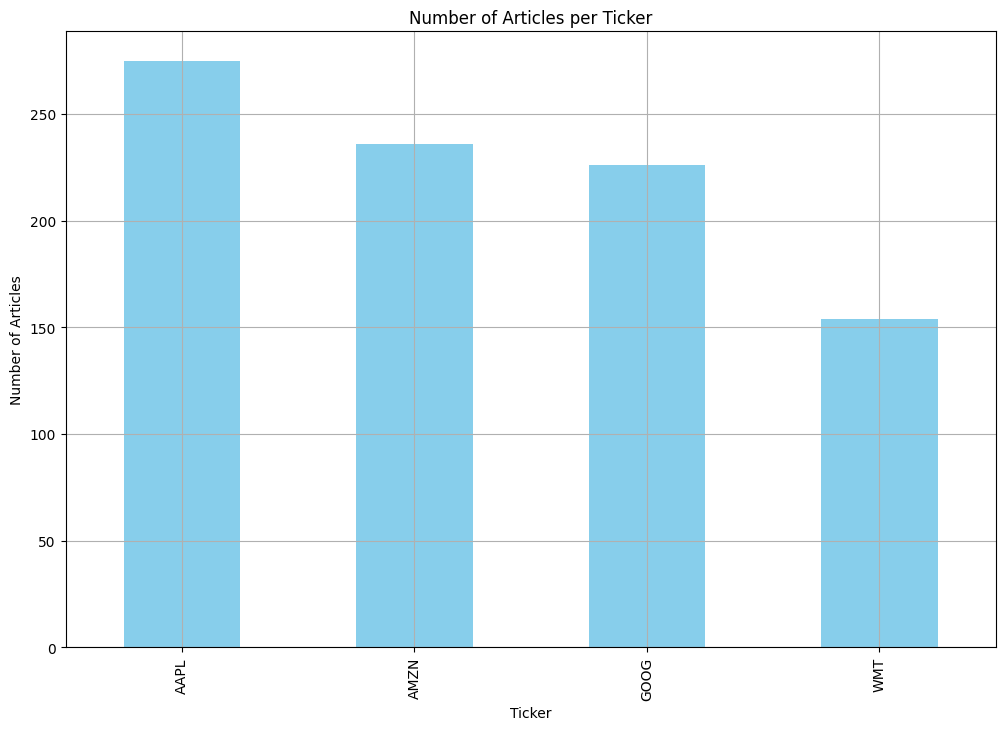

In [ ]:
# Plot: Number of Articles per Ticker
articles_per_ticker = df_sorted['Ticker'].value_counts()

plt.figure(figsize=(12, 8))
articles_per_ticker.plot(kind='bar', color='skyblue') # Generate a bar plot with 'skyblue' color for the bars
plt.title('Number of Articles per Ticker')
plt.xlabel('Ticker')
plt.ylabel('Number of Articles')
plt.xticks(rotation=90)
plt.grid(True)
plt.show()# Display the plot

# **Mean VADER Sentiment Trend for AAPL Per Day**

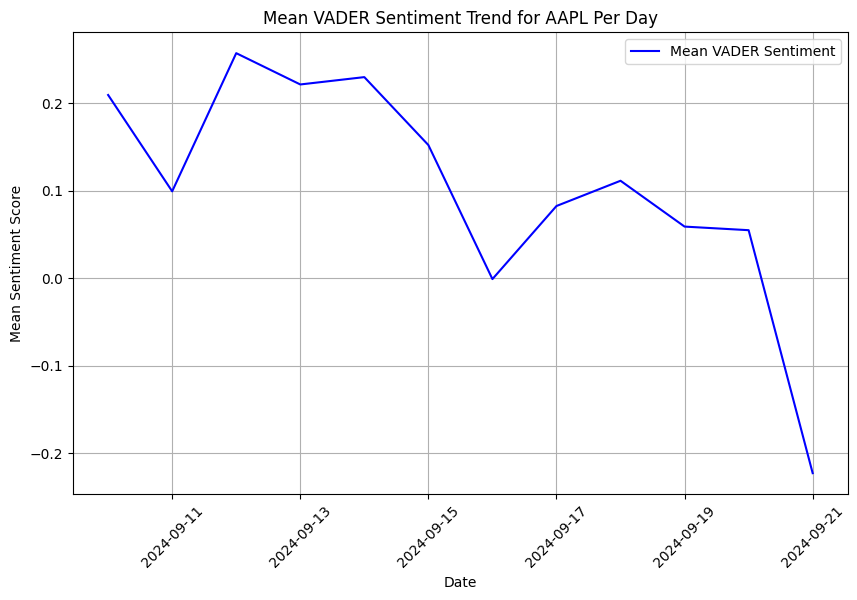

In [ ]:
ticker = 'AAPL'  # Set the stock ticker symbol (replace 'AAPL' with any ticker of your choice)
ticker_df = df_sorted[df_sorted['Ticker'] == ticker]

# Group the filtered DataFrame by 'Date' and calculate the mean sentiment score per day
daily_mean_sentiment = ticker_df.groupby('Date')['VADER_Sentiment'].mean()

# Plot the mean sentiment per day
plt.figure(figsize=(10, 6))
plt.plot(daily_mean_sentiment.index, daily_mean_sentiment.values, color='blue', label='Mean VADER Sentiment')
plt.title(f'Mean VADER Sentiment Trend for {ticker} Per Day')
plt.xlabel('Date')
plt.ylabel('Mean Sentiment Score')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()

# **Stock Prices AAPL (2024-09-10 to 2024-09-22)**

         Date  VADER_Sentiment
0  2024-09-10         0.209378
1  2024-09-11         0.099261
2  2024-09-12         0.257174
3  2024-09-13         0.221404
4  2024-09-14         0.229800
5  2024-09-15         0.152145
6  2024-09-16        -0.001029
7  2024-09-17         0.082496
8  2024-09-18         0.111354
9  2024-09-19         0.058964
10 2024-09-20         0.054856
11 2024-09-21        -0.222840


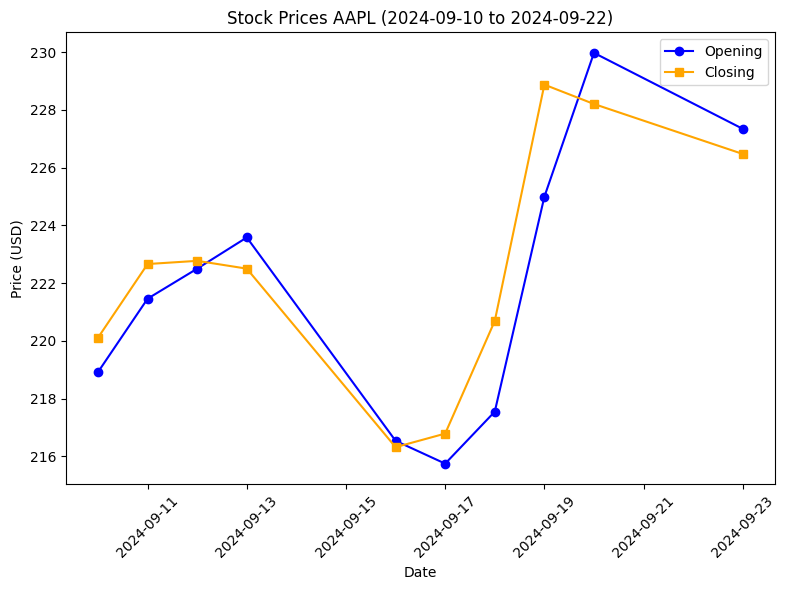

In [ ]:
# Import yfinance for fetching stock data
import yfinance as yf

# Filter the sorted DataFrame to include only rows where the ticker is 'AAPL'
df_apple = df_sorted[df_sorted['Ticker'] == 'AAPL']

# Group the filtered DataFrame by 'Date' and calculate the mean sentiment score per day
df_apple_daily = df_apple.groupby('Date').agg({
    'VADER_Sentiment': 'mean'  # Calculate the mean VADER sentiment score for each day
}).reset_index()

# Print the resulting DataFrame for daily sentiment scores
print(df_apple_daily)

# Fetch historical stock data for AAPL from yfinance for a specific date range
aapl = yf.Ticker("AAPL")  # Create a Ticker object for Apple (AAPL)
stock_data = aapl.history(start="2024-09-10", end="2024-09-24")  # Fetch stock data from yfinance

# Plot the stock data (Opening and Closing prices)
plt.figure(figsize=(8, 6))  # Set the figure size

# Plot the 'Open' stock prices with a blue line and circle markers
plt.plot(stock_data.index, stock_data['Open'], marker='o', label='Opening', color='blue')

# Plot the 'Close' stock prices with an orange line and square markers
plt.plot(stock_data.index, stock_data['Close'], marker='s', label='Closing', color='orange')
plt.title('Stock Prices AAPL (2024-09-10 to 2024-09-22)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
# Rotate the x-axis labels (dates) by 45 degrees for better readability
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
# Display the plot
plt.show()



# **Mean Sentiment per Date for Each Ticker**

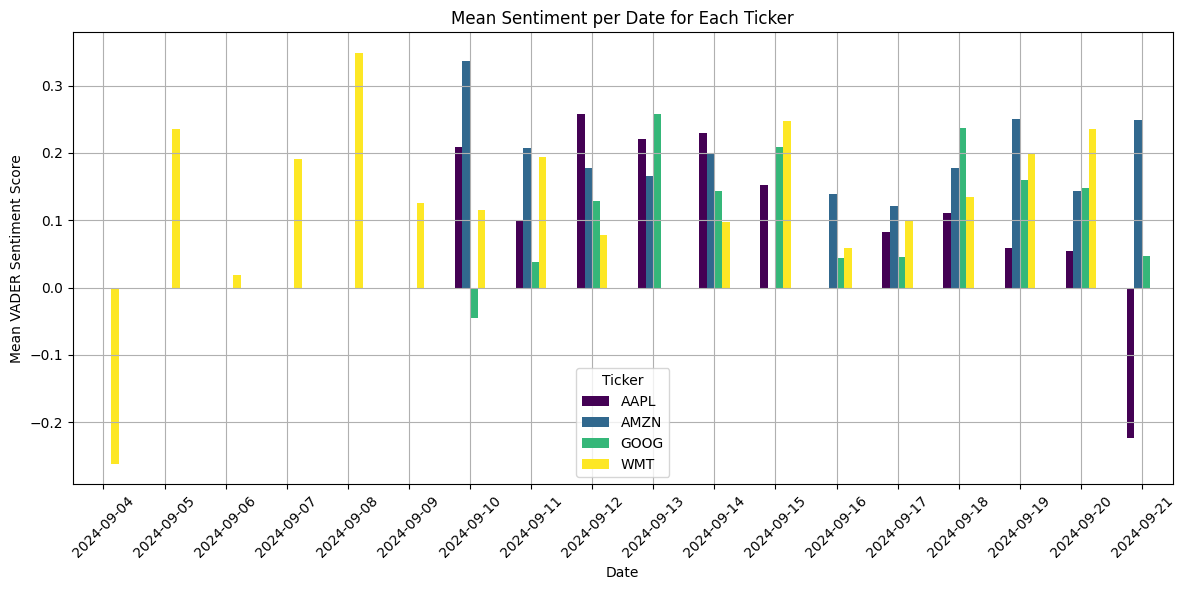

In [ ]:
# Group by date and ticker to calculate the mean sentiment for each ticker per date
mean_sentiment_by_date = df_sorted.groupby(['Date', 'Ticker'])['VADER_Sentiment'].mean().unstack()

# Convert the date index to just the date without time
mean_sentiment_by_date.index = mean_sentiment_by_date.index.strftime('%Y-%m-%d')

# Plot the data with different colors for each ticker
mean_sentiment_by_date.plot(kind='bar', figsize=(12, 6), colormap='viridis')
plt.title('Mean Sentiment per Date for Each Ticker')
plt.xlabel('Date')
plt.ylabel('Mean VADER Sentiment Score')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(title='Ticker')
plt.tight_layout()

# Show the plot
plt.show()

# **Sentiment Analysis using VADER and TextBlob on Kaggle Dataset**
## **Project Overview**
This project performs sentiment analysis on a Kaggle dataset (all-data.csv) using two sentiment analysis tools: VADER (Valence Aware Dictionary and sEntiment Reasoner) and TextBlob. It compares the accuracy and performance of these two tools by applying them to a set of headlines and evaluating the results against the true sentiment labels provided in the dataset.

## **Key Features:**


*   VADER Sentiment Analysis: This lexicon and rule-based sentiment analysis tool is designed for analyzing social media text, but it works well with other types of text as well.
*   TextBlob Sentiment Analysis: A library for processing textual data, offering simple API for common natural language processing tasks such as part-of-speech tagging, noun phrase extraction, and sentiment analysis.


*   Evaluation Metrics: Both models are evaluated using accuracy, classification reports, and confusion matrices.
## **Dataset**
The dataset used (all-data.csv) was sourced from Kaggle and contains two main columns:


*   True_Sentiment: The actual sentiment label for the headline (positive, negative, or neutral).
*   Headline: The text of the news headline for which the sentiment needs to be predicted.








VADER Accuracy: 55.03%
              precision    recall  f1-score   support

    negative       0.43      0.26      0.32       604
     neutral       0.70      0.56      0.62      2878
    positive       0.41      0.66      0.51      1363

    accuracy                           0.55      4845
   macro avg       0.51      0.49      0.48      4845
weighted avg       0.59      0.55      0.55      4845

TextBlob Accuracy: 58.53%
              precision    recall  f1-score   support

    negative       0.31      0.08      0.13       604
     neutral       0.62      0.85      0.72      2878
    positive       0.47      0.25      0.32      1363

    accuracy                           0.59      4845
   macro avg       0.47      0.39      0.39      4845
weighted avg       0.54      0.59      0.53      4845



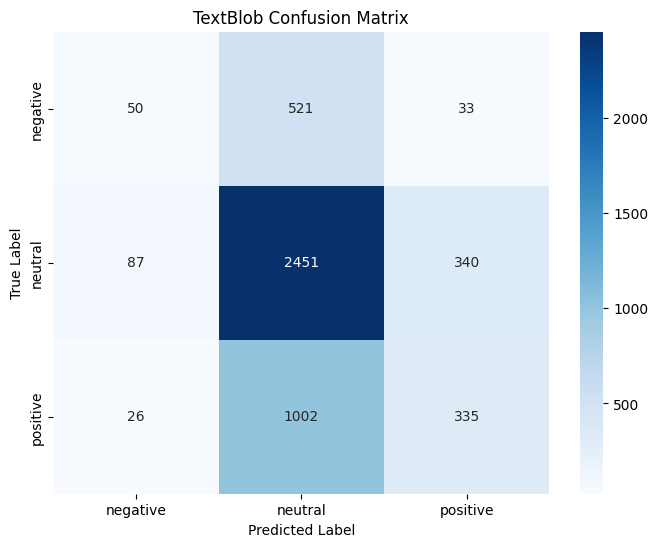

In [ ]:
import pandas as pd  # Library for data manipulation and analysis
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer  # VADER sentiment analysis tool
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  # Metrics for evaluating model performance
import matplotlib.pyplot as plt  # For plotting
import seaborn as sns  # For creating heatmaps
from textblob import TextBlob  # TextBlob sentiment analysis tool

# Load the dataset
data = pd.read_csv('/content/Kaggel dataset.csv', encoding='ISO-8859-1')

# Rename columns for clarity
data.columns = ['True_Sentiment', 'Headline']  # 'True_Sentiment' is the actual sentiment, 'Headline' is the text

# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Function to classify sentiment based on VADER's compound score
def vader_sentiment_classification(headline):
    # Get the compound sentiment score for the headline
    sentiment_score = analyzer.polarity_scores(headline)['compound']

    # Classify as 'positive', 'neutral', or 'negative' based on thresholds
    if sentiment_score >= 0.2:
        return 'positive'
    elif sentiment_score <= -0.2:
        return 'negative'
    else:
        return 'neutral'

# Function to classify sentiment based on TextBlob's polarity score
def textblob_sentiment_classification(headline):
    # Get the polarity score using TextBlob
    analysis = TextBlob(headline)
    sentiment_score = analysis.sentiment.polarity

    # Classify as 'positive', 'neutral', or 'negative' based on thresholds
    if sentiment_score > 0.2:
        return 'positive'
    elif sentiment_score < -0.2:
        return 'negative'
    else:
        return 'neutral'

# Apply VADER sentiment analysis to each headline in the dataset
data['Predicted_Sentiment'] = data['Headline'].apply(vader_sentiment_classification)

# Apply TextBlob sentiment analysis to each headline in the dataset
data['Predicted_Sentiment_TextBlob'] = data['Headline'].apply(textblob_sentiment_classification)

# Check accuracy of VADER by comparing predicted sentiment with true labels
accuracy = accuracy_score(data['True_Sentiment'].str.strip().str.lower(), data['Predicted_Sentiment'])
# Generate a classification report for VADER sentiment analysis
classification_rep = classification_report(data['True_Sentiment'].str.strip().str.lower(), data['Predicted_Sentiment'])

# Check accuracy of TextBlob by comparing predicted sentiment with true labels
accuracy_textblob = accuracy_score(data['True_Sentiment'].str.strip().str.lower(), data['Predicted_Sentiment_TextBlob'])
# Generate a classification report for TextBlob sentiment analysis
classification_rep_textblob = classification_report(data['True_Sentiment'].str.strip().str.lower(), data['Predicted_Sentiment_TextBlob'])

# Print VADER results: accuracy and classification report
print(f'VADER Accuracy: {accuracy * 100:.2f}%')
print(classification_rep)

# Print TextBlob results: accuracy and classification report
print(f'TextBlob Accuracy: {accuracy_textblob * 100:.2f}%')
print(classification_rep_textblob)

# Confusion Matrix for VADER
vader_conf_matrix = confusion_matrix(data['True_Sentiment'].str.strip().str.lower(), data['Predicted_Sentiment'])
plt.figure(figsize=(8,6))  # Set figure size
# Create a heatmap for VADER's confusion matrix
sns.heatmap(vader_conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('VADER Confusion Matrix')  # Set the title of the plot
plt.xlabel('Predicted Label')  # Set x-axis label
plt.ylabel('True Label')  # Set y-axis label
plt.show()  # Display the heatmap

# Confusion Matrix for TextBlob
textblob_conf_matrix = confusion_matrix(data['True_Sentiment'].str.strip().str.lower(), data['Predicted_Sentiment_TextBlob'])
plt.figure(figsize=(8,6))  # Set figure size
# Create a heatmap for TextBlob's confusion matrix
sns.heatmap(textblob_conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('TextBlob Confusion Matrix')  # Set the title of the plot
plt.xlabel('Predicted Label')  # Set x-axis label
plt.ylabel('True Label')  # Set y-axis label
plt.show()  # Display the heatmap
